In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load EEG Dataset

In [3]:
data = np.load("../eeg_processed/eeg_data.npz")
X_main, y = data['X'], data['y']
print(f"X (n_trails, n_channels, n_samples) : {X_main.shape}")
print(f"y (n_trails, ) : {y.shape}")

X (n_trails, n_channels, n_samples) : (1799, 16, 500)
y (n_trails, ) : (1799,)


# Features 

## 1. Extract Time Related Features

In [5]:
from scipy.stats import (skew, 
                        kurtosis)

Skewness

- Normally skewed distribution - if the skewness values are within -0.5 to 0.5
- Moderate skewed distribution - if the skewness values are within -0.5 to -1 for negatively moderate skewed and 0.5 to 1 for postively moderate skewed

- Highly skewed distribution - if the skewness values are outside of -1 and 1 


Kurtosis - statistical measure that describes the heaviness of a distribution's tails and the concentration of data around the mean

- Normal distribution has a kurtosis of 3

- Leptokurtic - with a kurtosis value greater than 3 - this indicates heavier tails and a more peaked center

- Platykurtic - with a kurtosis value lesser than 3 - this indicates lighter tails and a flatter center

In [6]:
def extract_time_features(X):
    """Extract time-domain features"""
    n_trials, n_channels, n_samples = X.shape
    
    features = []
    for trial in range(n_trials):
        trial_features = []
        
        for ch in range(n_channels):
            signal = X[trial, ch, :]
            
            # Statistical features
            trial_features.extend([
                np.mean(signal),          # Mean
                np.std(signal),           # Standard deviation
                np.var(signal),           # Variance
                skew(signal),             # Skewness
                kurtosis(signal),         # Kurtosis
                np.max(signal),           # Maximum
                np.min(signal),           # Minimum
                np.ptp(signal),           # Peak-to-peak
                np.median(signal),        # Median
                np.mean(np.abs(signal)),  # Mean absolute value
            ])
            
            # Zero crossing rate
            zero_crossings = np.sum(np.diff(np.sign(signal)) != 0)
            trial_features.append(zero_crossings)
            
            # Root mean square
            rms = np.sqrt(np.mean(signal**2))
            trial_features.append(rms)
            
        features.append(trial_features)
        
    return np.array(features)

In [10]:
try:
    X_time_features = extract_time_features(X_main)
    assert(X_time_features.shape[0] == X_main.shape[0])
    print("---- Success - Time Related Features ----")
except:
    print("---- Failure - Time Related Features ----")

---- Success - Time Related Features ----


In [18]:
col_names= ["mean", "std", "variance", "skeeness","kurtosis", "maximum", 
        "minimum", "peak-to-peak", "median", "mean_absolute_value","zero_crossing_rate","root_mean_square"]

timefeature_col_names = [f"electrode_{i}_{col_name}" for i in range(16) for col_name in col_names]

X_time_features = pd.DataFrame(X_time_features)
X_time_features.columns = timefeature_col_names

In [75]:
def plot_time_series(X_main, trail, electrode):
    plt.figure(figsize = (15, 10))
    plt.plot(X_main[trail, 1, :],  label = "EEG Signal")
    plt.axhline(y = np.mean(X_main[trail, electrode, :]), 
                color = 'r', 
                linestyle = '--', 
                label = f"Mean Line - {np.round(np.mean(X_main[trail, electrode, :]), 2)}")
    plt.axhline(y = np.median(X_main[trail, electrode, :]), 
                color = 'g', 
                linestyle = '--', 
                label = f"Median Line - {np.round(np.median(X_main[trail, electrode, :]), 2)}")
    plt.axhline(y = np.max(X_main[trail, electrode, :]), 
                linestyle = '--', 
                label = f"Max Line - {np.round(np.max(X_main[trail, electrode, :]), 2)}")

    plt.axhline(y = np.min(X_main[trail, electrode, :]), 
                color = 'y',
                linestyle = '--', 
                label = f"Min Line - {np.round(np.min(X_main[trail, electrode, :]), 2)}")

    plt.axhline(y = np.mean(X_main[trail, electrode, :]) + np.std(X_main[trail, electrode, :]), 
                color = 'pink',
                linestyle = '--', 
                label = f"Standard Deviation (Upper) Line - {np.round(np.mean(X_main[trail, electrode, :]) + np.std(X_main[trail, electrode, :]), 2)}")

    plt.axhline(y = np.mean(X_main[trail, electrode, :]) - np.std(X_main[trail, electrode, :]), 
                color = 'pink',
                linestyle = '--', 
                label = f"Standard Deviation (lower) Line - {np.round(np.mean(X_main[trail, electrode, :]) - np.std(X_main[trail, electrode, :]), 2)}")


    plt.title(f"Skewness - {skew(X_main[trail, electrode, :])}, Kurtosis - {kurtosis(X_main[trail, electrode, :])}, Trail - {trail}, Electrode - {electrode}")

    plt.legend()
    plt.show()

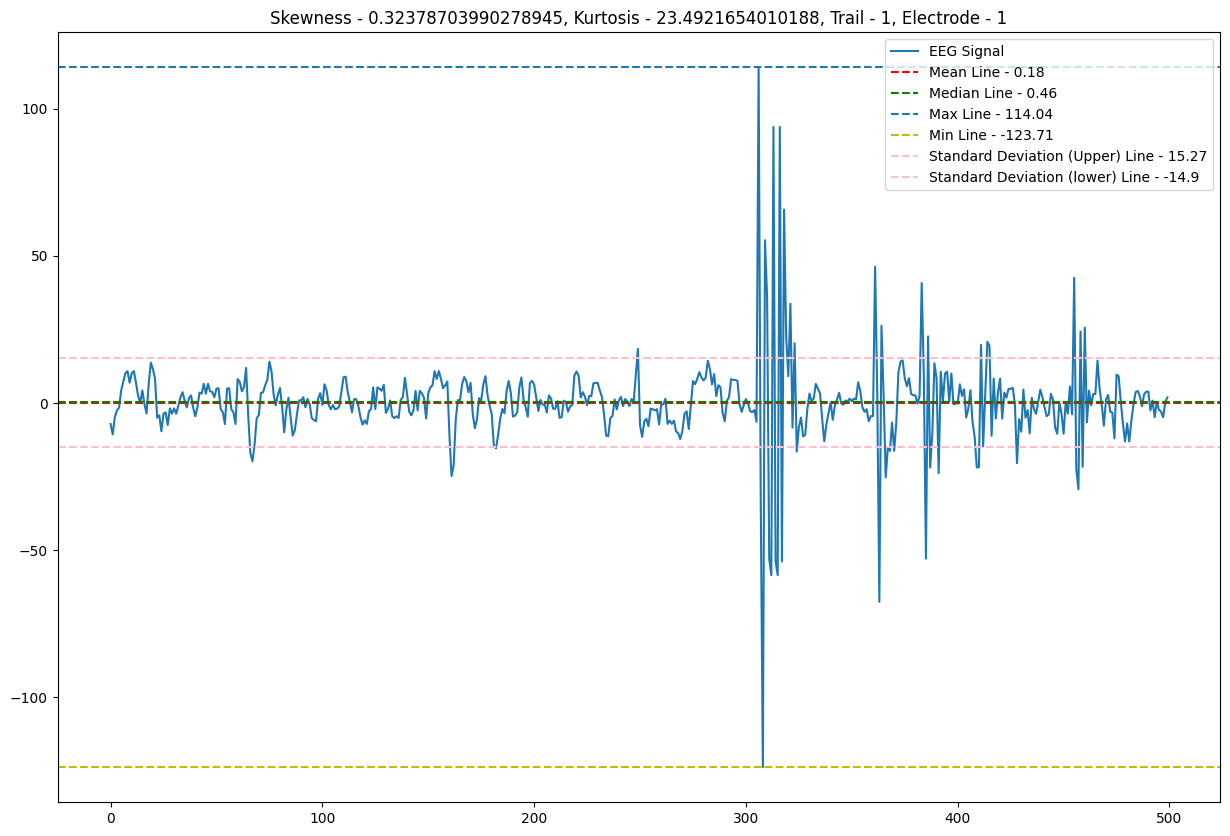

In [76]:
plot_time_series(X_main, trail = 1, electrode = 1)

# 2 . Frequency Related Features

In [77]:
from scipy.signal import welch

In [ ]:
def extract_frequency_features(X, sfreq, freq_bands):
        """Extract frequency-domain features"""
        n_trials, n_channels, n_samples = X.shape
        
        features = []
        for trial in range(n_trials):
            trial_features = []
            
            for ch in range(n_channels):
                signal = X[trial, ch, :]
                
                # Power spectral density
                freqs, psd = welch(signal, fs=sfreq, nperseg=min(256, n_samples//4))
                
                # Band power features
                for band_name, (low, high) in freq_bands.items():
                    band_mask = (freqs >= low) & (freqs <= high)
                    band_power = np.sum(psd[band_mask])
                    trial_features.append(band_power)
                
                # Spectral features
                total_power = np.sum(psd)
                spectral_centroid = np.sum(freqs * psd) / total_power
                spectral_spread = np.sqrt(np.sum(((freqs - spectral_centroid)**2) * psd) / total_power)
                spectral_entropy = -np.sum((psd/total_power) * np.log2(psd/total_power + 1e-12))
                
                trial_features.extend([
                    total_power,
                    spectral_centroid,
                    spectral_spread,
                    spectral_entropy
                ])
                
                # Peak frequency
                peak_freq = freqs[np.argmax(psd)]
                trial_features.append(peak_freq)
                
            features.append(trial_features)
            
        return np.array(features)

In [ ]:
freq_bands = {'delta': (0.5, 4), 'theta': (4, 8), 'alpha': (8, 13),
 'beta': (13, 30), 'gamma': (30, 50)}
sfreq = 250
